ファイルを読み込みます: G:/共有ドライブ/GAP_長寿研/user/iwamoto/視線の動きの俊敏さ/data/shizuoka2023_EyeCenterAngle_saccade_analysis_vel30_excl5s_origin.csv
,区切りファイルとして読み込みます
データ読み込み完了: 732行, 32列
特徴量として使用: 28列
データサイズ: (732, 28)
データの標準化を実行中...
標準化完了
PCAの次元数を28に自動調整しました
PCAによる次元削減を実行中（次元数: 28）...
PCA完了: 累積寄与率 = 1.0000
UMAPによる次元削減を実行中（次元数: 2）...


c:\Users\user\anaconda3\envs\mci\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\user\anaconda3\envs\mci\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


UMAP次元削減完了
K-meansのエルボー法とシルエット分析を実行中...


c:\Users\user\anaconda3\envs\mci\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\user\anaconda3\envs\mci\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\user\anaconda3\envs\mci\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


クラスター数 2: イナーシャ = 2364.38, シルエットスコア = 0.5618
クラスター数 3: イナーシャ = 1452.21, シルエットスコア = 0.4887
クラスター数 4: イナーシャ = 1049.55, シルエットスコア = 0.5092


...

クラスター数 5: イナーシャ = 813.14, シルエットスコア = 0.4553
クラスター数 6: イナーシャ = 637.39, シルエットスコア = 0.4695
クラスター数 7: イナーシャ = 532.99, シルエットスコア = 0.4722


c:\Users\user\anaconda3\envs\mci\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


クラスター数 8: イナーシャ = 457.49, シルエットスコア = 0.4109
シルエットスコアに基づく最適クラスター数: 2
クラスター数を3に設定しました（最適値は2です）
クラスター 0: 202 ポイント
クラスター 1: 333 ポイント
クラスター 2: 197 ポイント


c:\Users\user\anaconda3\envs\mci\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


PCAの寄与率グラフを保存しました: G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\result\pca_explained_variance.png
K-meansのエルボー法グラフを保存しました: G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\result\kmeans_elbow_method.png
IDラベル付きUMAPプロットを保存しました: G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\result\umap_with_ids.png
クラスター情報付きデータを保存しました: G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\result\umap_clustered_data.csv

すべてのグラフを表示します...


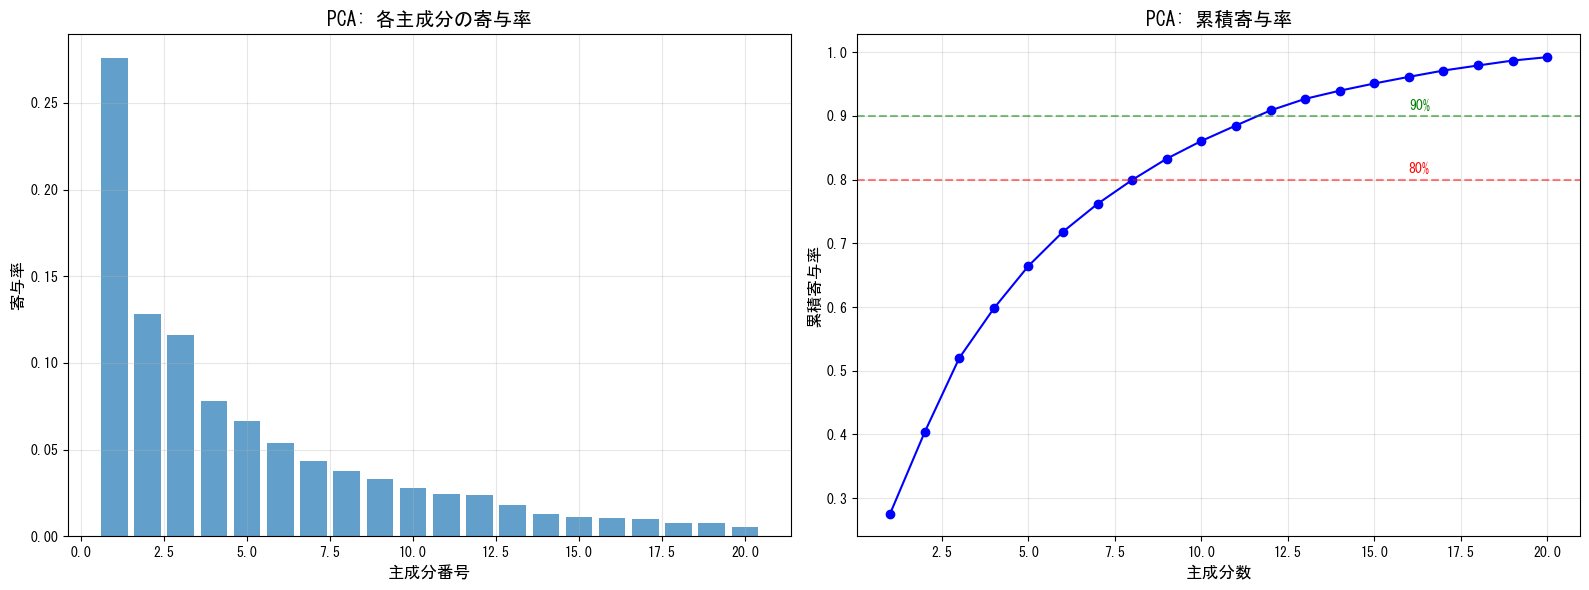

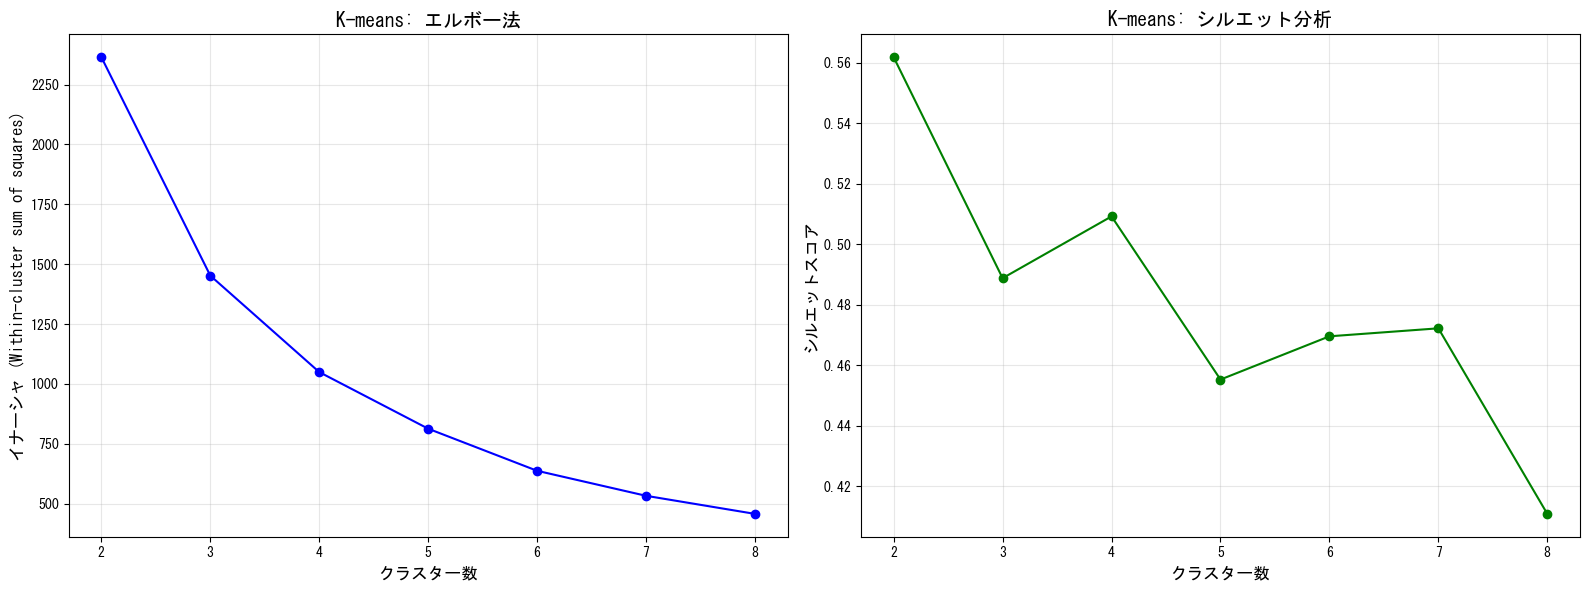

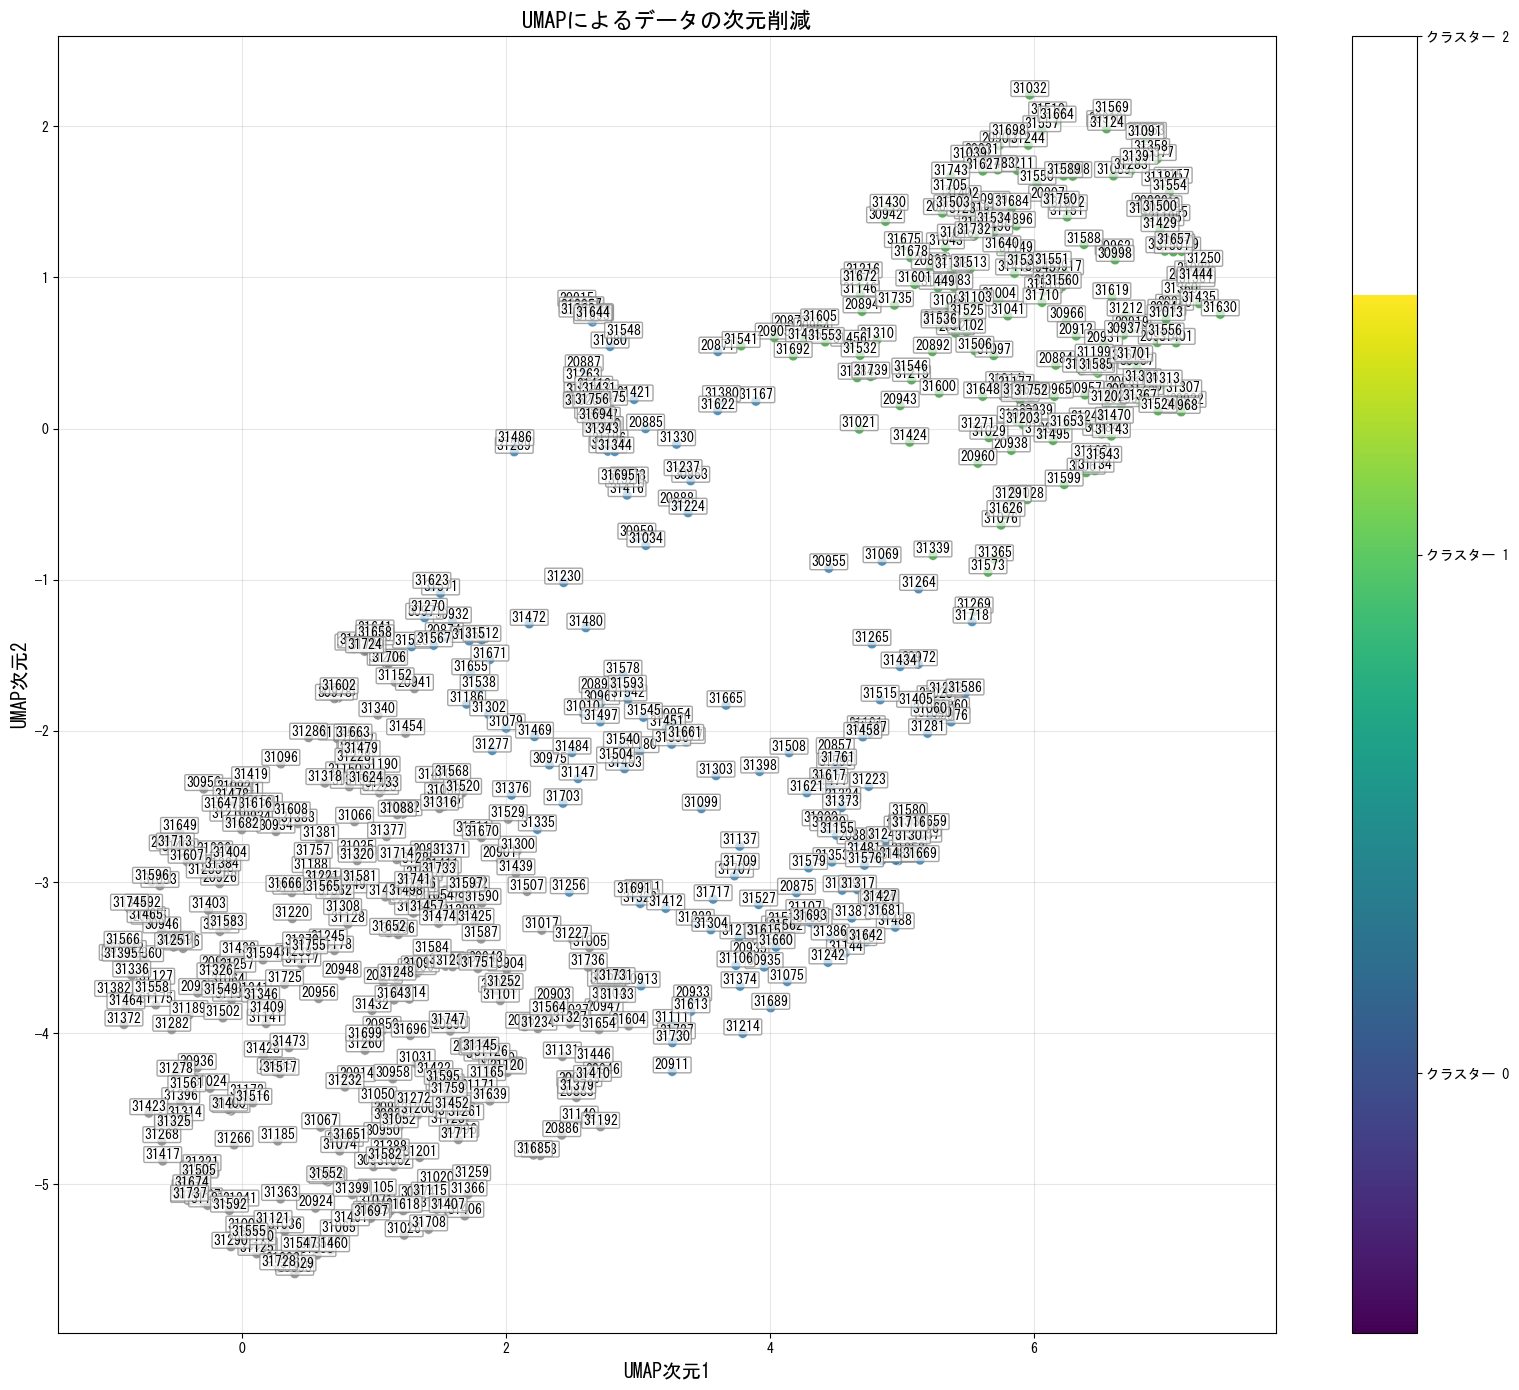

In [ ]:
# UMAPの図にIDを表示するための完全なコード

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from umap import UMAP
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os

# 日本語フォント設定（必要に応じて）
try:
    import matplotlib.font_manager as fm
    font_path = 'C:/Windows/Fonts/msgothic.ttc'  # Windowsの場合のMSゴシック
    if os.path.exists(font_path):
        prop = fm.FontProperties(fname=font_path)
        matplotlib.rcParams['font.family'] = prop.get_name()
except Exception:
    pass  # フォント設定に失敗しても処理を続行

class DimensionalityReducer:
    """データの次元削減を行うクラス"""
    
    def __init__(self, n_components_pca=None, n_components_umap=2, 
                 umap_n_neighbors=15, umap_min_dist=0.1, random_state=42):
        self.n_components_pca = n_components_pca  # Noneの場合は自動設定
        self.n_components_umap = n_components_umap
        self.umap_n_neighbors = umap_n_neighbors
        self.umap_min_dist = umap_min_dist
        self.random_state = random_state
        
        # モデルは後で初期化
        self.scaler = StandardScaler()
        self.pca = None  # データサイズを確認後に初期化
        self.umap = UMAP(
            n_neighbors=umap_n_neighbors,
            min_dist=umap_min_dist,
            n_components=n_components_umap,
            random_state=random_state
        )
        
        # 変換後のデータ
        self.X_scaled = None
        self.X_pca = None
        self.X_umap = None
        
    def fit_transform(self, X):
        """データに対してPCAとUMAPを適用する"""
        # データの標準化
        print("データの標準化を実行中...")
        self.X_scaled = self.scaler.fit_transform(X)
        print("標準化完了")
        
        # 適切なPCAの次元数を決定
        n_samples, n_features = self.X_scaled.shape
        max_components = min(n_samples, n_features)
        
        if self.n_components_pca is None or self.n_components_pca > max_components:
            # デフォルト値または大きすぎる場合は最大値に設定
            self.n_components_pca = max_components
            print(f"PCAの次元数を{self.n_components_pca}に自動調整しました")
        
        # PCAの初期化と適用
        print(f"PCAによる次元削減を実行中（次元数: {self.n_components_pca}）...")
        self.pca = PCA(n_components=self.n_components_pca, random_state=self.random_state)
        self.X_pca = self.pca.fit_transform(self.X_scaled)
        
        explained_variance_ratio = self.pca.explained_variance_ratio_
        cumulative_variance = np.cumsum(explained_variance_ratio)
        print(f"PCA完了: 累積寄与率 = {cumulative_variance[-1]:.4f}")
        
        # UMAPの適用
        print(f"UMAPによる次元削減を実行中（次元数: {self.n_components_umap}）...")
        self.X_umap = self.umap.fit_transform(self.X_pca)
        print("UMAP次元削減完了")
        
        return self.X_umap
    
    def plot_pca_explained_variance(self, max_components=None):
        """PCAの寄与率をプロットする"""
        if self.pca is None:
            raise ValueError("先にfit_transformを実行してください")
        
        # 説明済み分散比の取得
        explained_variance_ratio = self.pca.explained_variance_ratio_
        cumulative_variance = np.cumsum(explained_variance_ratio)
        
        # 表示する成分数の設定
        if max_components is None:
            max_components = len(explained_variance_ratio)
        else:
            max_components = min(max_components, len(explained_variance_ratio))
        
        # プロットの作成
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        # 寄与率のプロット
        ax1.bar(range(1, max_components + 1), explained_variance_ratio[:max_components], alpha=0.7)
        ax1.set_xlabel('主成分番号', fontsize=12)
        ax1.set_ylabel('寄与率', fontsize=12)
        ax1.set_title('PCA: 各主成分の寄与率', fontsize=14)
        ax1.grid(True, alpha=0.3)
        
        # 累積寄与率のプロット
        ax2.plot(range(1, max_components + 1), cumulative_variance[:max_components], 'bo-')
        ax2.axhline(y=0.8, color='r', linestyle='--', alpha=0.5)  # 80%の水平線
        ax2.axhline(y=0.9, color='g', linestyle='--', alpha=0.5)  # 90%の水平線
        ax2.text(max_components * 0.8, 0.81, '80%', color='r', fontsize=10)
        ax2.text(max_components * 0.8, 0.91, '90%', color='g', fontsize=10)
        ax2.set_xlabel('主成分数', fontsize=12)
        ax2.set_ylabel('累積寄与率', fontsize=12)
        ax2.set_title('PCA: 累積寄与率', fontsize=14)
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        return fig

# データの読み込みと前処理
def load_data(file_path):
    """ファイルを読み込み、前処理を行う"""
    print(f"ファイルを読み込みます: {file_path}")
    
    try:
        # 区切り文字を検出
        with open(file_path, 'r') as f:
            first_line = f.readline().strip()
            
        separator = '\t' if '\t' in first_line else (',' if ',' in first_line else '\t')
        print(f"{separator}区切りファイルとして読み込みます")
        
        # CSVファイルの読み込み
        df = pd.read_csv(file_path, sep=separator)
        print(f"データ読み込み完了: {df.shape[0]}行, {df.shape[1]}列")
        
        # 列が1つだけの場合の処理
        if df.shape[1] == 1:
            print("列が1つだけです。カンマ区切りでの再分割を試みます")
            first_col_name = df.columns[0]
            if ',' in str(df[first_col_name].iloc[0]):
                temp_df = df[first_col_name].str.split(',', expand=True)
                headers = temp_df.iloc[0]
                temp_df = temp_df.iloc[1:]
                temp_df.columns = headers
                df = temp_df
                print("カンマ区切りで再分割しました")
        
        # 数値列に変換
        for col in df.columns:
            if col not in ['freq', 'power_spectrum', 'InspectionDateAndId']:
                try:
                    df[col] = pd.to_numeric(df[col])
                except:
                    pass
        
        # 数値列のみを選択
        numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
        print(f"特徴量として使用: {len(numeric_cols)}列")
        
        # 特徴量が空の場合はエラー
        if not numeric_cols:
            raise ValueError("数値特徴量が見つかりません")
        
        # 数値データを抽出
        X = df[numeric_cols].copy()
        X = X.fillna(X.mean())  # 欠損値を平均値で補完
        
        return df, X, numeric_cols
        
    except Exception as e:
        print(f"エラー: {str(e)}")
        raise

def find_optimal_k(embedding, max_clusters=10):
    """エルボー法とシルエットスコアで最適なクラスター数を探索"""
    print("K-meansのエルボー法とシルエット分析を実行中...")
    
    # クラスター数ごとのイナーシャとシルエットスコアを計算
    inertia_values = []
    silhouette_values = []
    k_values = range(2, max_clusters + 1)
    
    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(embedding)
        inertia_values.append(kmeans.inertia_)
        
        # シルエットスコアの計算（2クラスター以上でのみ計算可能）
        silhouette_avg = silhouette_score(embedding, labels)
        silhouette_values.append(silhouette_avg)
        print(f"クラスター数 {k}: イナーシャ = {kmeans.inertia_:.2f}, シルエットスコア = {silhouette_avg:.4f}")
    
    # 最適なクラスター数の特定（シルエットスコアが最大のもの）
    optimal_k = k_values[np.argmax(silhouette_values)]
    print(f"シルエットスコアに基づく最適クラスター数: {optimal_k}")
    
    # エルボー法とシルエットスコアのプロット
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # エルボー法（イナーシャのプロット）
    ax1.plot(k_values, inertia_values, 'bo-')
    ax1.set_xlabel('クラスター数', fontsize=12)
    ax1.set_ylabel('イナーシャ (Within-cluster sum of squares)', fontsize=12)
    ax1.set_title('K-means: エルボー法', fontsize=14)
    ax1.grid(True, alpha=0.3)
    
    # シルエットスコアのプロット
    ax2.plot(k_values, silhouette_values, 'go-')
    ax2.set_xlabel('クラスター数', fontsize=12)
    ax2.set_ylabel('シルエットスコア', fontsize=12)
    ax2.set_title('K-means: シルエット分析', fontsize=14)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    return optimal_k, fig, inertia_values, silhouette_values, k_values

# 新たに実装した関数: UMAPの図にIDを表示
def plot_clustered_umap_with_ids(df, embedding, clusters, id_column='InspectionDateAndId', 
                         id_type='suffix', fontsize=10, point_size=50, 
                         alpha=0.8, colorbar=True):
    """
    クラスターで色分けしたUMAP可視化にIDを表示する関数
    
    Parameters:
    -----------
    df : pandas.DataFrame
        データフレーム（IDを含む）
    embedding : numpy.ndarray
        UMAPによる2次元埋め込み座標
    clusters : numpy.ndarray
        各ポイントのクラスターID
    id_column : str, optional
        ID列の列名
    id_type : str, optional
        'full'=完全なID, 'suffix'=末尾のみ, 'prefix'=先頭のみ
    fontsize : int, optional
        IDのフォントサイズ
    point_size : int, optional
        ポイントのサイズ
    alpha : float, optional
        ポイントの透明度
    colorbar : bool, optional
        カラーバーを表示するか
        
    Returns:
    --------
    fig : matplotlib.figure.Figure
        作成された図のオブジェクト
    ax : matplotlib.axes.Axes
        作成された軸のオブジェクト
    """
    # 図の作成
    fig, ax = plt.subplots(figsize=(16, 14))
    
    # クラスターごとに色を設定
    # カラーマップを3つのクラスターに合わせて設定
    colors = ['#1f77b4', '#7f7f7f', '#2ca02c', '#ff7f0e', '#9467bd']  # 青、グレー、緑、オレンジ、紫
    
    # クラスター数に応じて色を繰り返す
    n_clusters = len(np.unique(clusters))
    colors = colors[:n_clusters]  # 必要な色だけ取得
    
    # クラスターごとにポイントを描画
    scatter = ax.scatter(
        embedding[:, 0], 
        embedding[:, 1], 
        c=[colors[c] for c in clusters], 
        s=point_size,
        alpha=alpha,
        edgecolor='white',
        linewidth=0.5
    )
    
    # IDを表示
    for i, (x, y) in enumerate(embedding):
        full_id = str(df.iloc[i][id_column])
        
        # IDの処理（表示方法に応じて）
        if id_type == 'suffix' and '_' in full_id:
            # '_'で区切られた末尾の部分を表示
            display_id = full_id.split('_')[-1]
        elif id_type == 'prefix' and '_' in full_id:
            # '_'で区切られた先頭の部分を表示
            display_id = full_id.split('_')[0]
        else:
            # 完全なIDを表示
            display_id = full_id
        
        # テキスト追加（背景を白色に）
        ax.text(
            x, y, 
            display_id,
            fontsize=fontsize,
            ha='center',  # 水平方向の位置揃え
            va='bottom',  # 垂直方向の位置揃え
            bbox=dict(
                boxstyle="round,pad=0.1",
                fc="white",
                ec="gray",
                alpha=0.7
            )
        )
    
    # カラーバーを追加（オプション）
    if colorbar:
        cbar = plt.colorbar(plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(0, n_clusters-1)), ax=ax)
        cbar.set_ticks(np.arange(n_clusters) + 0.5)
        cbar.set_ticklabels([f'クラスター {i}' for i in range(n_clusters)])
    
    # 軸ラベルとタイトル
    ax.set_xlabel('UMAP次元1', fontsize=14)
    ax.set_ylabel('UMAP次元2', fontsize=14)
    ax.set_title('UMAPによるデータの次元削減', fontsize=16)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    
    return fig, ax

# メイン処理
if __name__ == "__main__":
    # ファイルパスの設定
    path = "G:/共有ドライブ/GAP_長寿研/user/iwamoto/視線の動きの俊敏さ/data"
    file_path = f"{path}/features_test_nolabel.csv"
    
    # データの読み込みと前処理
    df, X, numeric_cols = load_data(file_path)
    
    # データのサイズを確認
    print(f"データサイズ: {X.shape}")
    
    # 次元削減の実行 (PCAの次元数は自動調整)
    reducer = DimensionalityReducer(n_components_pca=None, n_components_umap=2)
    embedding = reducer.fit_transform(X)
    
    # PCAの寄与率をプロット
    pca_fig = reducer.plot_pca_explained_variance(max_components=20)  # 最初の20成分のみ表示
    
    # K-meansのエルボー法とシルエット分析
    optimal_k, kmeans_fig, _, _, _ = find_optimal_k(embedding, max_clusters=8)
    
    # ユーザーが指定したクラスター数または最適なクラスター数を使用
    n_clusters = 3  
    print(f"クラスター数を{n_clusters}に設定しました（最適値は{optimal_k}です）")
    
    # クラスタリングの実行
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(embedding)
    
    # クラスター情報をデータフレームに追加
    df['cluster'] = clusters
    df['umap_x'] = embedding[:, 0]
    df['umap_y'] = embedding[:, 1]
    
    # クラスターごとのポイント数をカウント
    cluster_counts = np.bincount(clusters)
    for i, count in enumerate(cluster_counts):
        print(f"クラスター {i}: {count} ポイント")
    
    # 結果を保存するディレクトリ
    result_path = r"G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\result"
    os.makedirs(result_path, exist_ok=True)
    
    # PCAの寄与率グラフを保存
    pca_plot_path = os.path.join(result_path, "pca_explained_variance.png")
    pca_fig.savefig(pca_plot_path, dpi=300, bbox_inches='tight')
    print(f"PCAの寄与率グラフを保存しました: {pca_plot_path}")
    
    # K-meansのエルボー法グラフを保存
    kmeans_plot_path = os.path.join(result_path, "kmeans_elbow_method.png")
    kmeans_fig.savefig(kmeans_plot_path, dpi=300, bbox_inches='tight')
    print(f"K-meansのエルボー法グラフを保存しました: {kmeans_plot_path}")
    
    # 新しい関数を使用してUMAPプロットを作成（IDラベル付き）
    fig, ax = plot_clustered_umap_with_ids(
        df,
        embedding,
        clusters,
        id_type='suffix',     # 'suffix', 'prefix', 'full' から選択
        fontsize=10,          # IDのフォントサイズ
        point_size=50,        # ポイントのサイズ
        alpha=0.8,            # ポイントの透明度
        colorbar=True         # カラーバーを表示するか
    )
    
    # IDラベル付きプロットを保存
    plot_path = os.path.join(result_path, "umap_with_ids.png")
    fig.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"IDラベル付きUMAPプロットを保存しました: {plot_path}")
    
    # データを保存
    csv_path = os.path.join(result_path, "umap_clustered_data.csv")
    df.to_csv(csv_path, index=False)
    print(f"クラスター情報付きデータを保存しました: {csv_path}")
    
    # プロットを表示
    print("\nすべてのグラフを表示します...")
    plt.show()